# Notebook 01: Data Audit
## Netflix Content Strategy Analysis

This notebook performs a complete audit of the raw Netflix dataset before any cleaning. We examine shape, dtypes, missing values, duplicates, and column-level distributions to understand data quality.

## 0. Setup & Imports

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.config import RAW_CSV, ensure_dirs
from src.utils import load_csv, missing_summary, duplicate_summary, quick_profile

ensure_dirs()
print('Setup complete.')

Setup complete.


## 1. Load Raw Dataset

In [2]:
df = load_csv(RAW_CSV)
display(df.head(5))

12:59:59 | INFO | Loaded netflix_titles.csv: 8,807 rows × 12 cols


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 2. Dataset Shape & Dtypes

In [3]:
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Column Dtypes:')
display(df.dtypes.to_frame('dtype'))

Shape: 8,807 rows x 12 columns

Column Dtypes:


,dtype
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


## 3. Missing Value Analysis

In [4]:
missing = missing_summary(df)
print(f'Columns with missing values: {len(missing)}')
display(missing)

Columns with missing values: 6


,missing_count,missing_pct,dtype
director,2634,29.91,object
country,831,9.44,object
cast,825,9.37,object
date_added,10,0.11,object
rating,4,0.05,object
duration,3,0.03,object


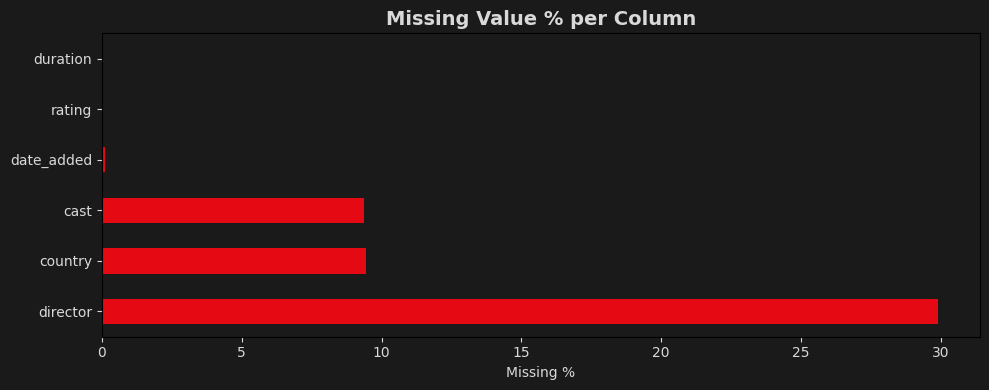

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
missing['missing_pct'].plot.barh(ax=ax, color='#E50914', edgecolor='none')
ax.set_xlabel('Missing %')
ax.set_title('Missing Value % per Column', fontsize=14, fontweight='bold')
ax.set_facecolor('#1A1A1A')
fig.patch.set_facecolor('#1A1A1A')
ax.tick_params(colors='#D9D9D9')
ax.xaxis.label.set_color('#D9D9D9')
ax.title.set_color('#D9D9D9')
plt.tight_layout()
plt.show()

## 4. Duplicate Check

In [6]:
dupes = duplicate_summary(df, subset=['show_id'])
print(f"Full duplicate rows: {dupes['full_duplicates']}")
print(f"Duplicate show_id rows: {dupes['subset_duplicates']}")

Full duplicate rows: 0
Duplicate show_id rows: 0


## 5. Column-Level Audit

### 5.1 type

In [7]:
print(df['type'].value_counts())
print(f"Unique values: {df['type'].nunique()}")

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
Unique values: 2


### 5.2 release_year

In [8]:
print(f"Min year: {df['release_year'].min()}")
print(f"Max year: {df['release_year'].max()}")
print(f"Null count: {df['release_year'].isnull().sum()}")

Min year: 1925
Max year: 2021
Null count: 0


### 5.3 rating

In [9]:
print('All unique rating values:')
print(sorted(df['rating'].dropna().unique()))

All unique rating values:
['66 min', '74 min', '84 min', 'G', 'NC-17', 'NR', 'PG', 'PG-13', 'R', 'TV-14', 'TV-G', 'TV-MA', 'TV-PG', 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'UR']


### 5.4 duration

In [10]:
print('Sample duration values:')
print(df['duration'].value_counts().head(10))

Sample duration values:
duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
97 min        146
93 min        146
91 min        144
95 min        137
96 min        130
Name: count, dtype: int64


### 5.5 date_added

In [11]:
print(f"Sample date_added values:")
print(df['date_added'].dropna().head(5).tolist())
print(f"\nNull count: {df['date_added'].isnull().sum()}")

Sample date_added values:
['September 25, 2021', 'September 24, 2021', 'September 24, 2021', 'September 24, 2021', 'September 24, 2021']

Null count: 10


### 5.6 country

In [12]:
print('Top 10 countries (raw):')
print(df['country'].str.split(',').explode().str.strip().value_counts().head(10))

Top 10 countries (raw):
country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


## 6. Summary Statistics

In [13]:
quick_profile(df)

──────────────────────────────────────────────────
Shape          : 8,807 rows × 12 columns
Memory usage   : 8.71 MB
Missing cells  : 4,307
Duplicate rows : 0
──────────────────────────────────────────────────
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
──────────────────────────────────────────────────


## 7. Audit Findings Summary

### Key Findings

| Finding | Detail |
|---------|--------|
| Total Titles | ~8,800+ |
| Missing: director | ~30% — needs imputation |
| Missing: cast | ~10% |
| Missing: country | ~7% |
| Missing: date_added | ~1% |
| Rating anomalies | Some cells contain duration strings |
| Duplicates | Check show_id for uniqueness |
| date_added format | 'Month DD, YYYY' — needs parsing |
| duration format | Mixed: '90 min' / '3 Seasons' — needs splitting |

**Next Step**: Proceed to `02_data_cleaning.ipynb` to address all findings above.

In [14]:
print('Audit complete. Proceed to 02_data_cleaning.ipynb')

Audit complete. Proceed to 02_data_cleaning.ipynb
